In [46]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
palette = "viridis"
sns.set_palette(palette)
MAX_ENERGY = 100.0

In [47]:
#plot mean and std of fitness , energy fitness, age_mass fitness

mean_fitness_seed_11 = np.load('./seed_11/mean_fitness_progress.npy')
mean_fitness_seed_7 = np.load('./seed_7/mean_fitness_progress.npy')
mean_fitness_seed_5 = np.load('./seed_5/mean_fitness_progress.npy')



def moving_average(arr, w):
    ma = np.convolve(arr, np.ones(w), mode='valid') / w
    pad_left = (w - 1) // 2
    pad_right = w - 1 - pad_left
    ma = np.pad(ma, (pad_left, pad_right), mode='constant', constant_values=0)
    ma[:w-1] = arr[:w-1]  # keep the first w-1 values as they are
    ma[-(w-1):] = arr[-(w-1):]  # keep the last w-1 values as they are
    return ma

moving_average_window = 5
mean_fitness_seed_11 = moving_average(mean_fitness_seed_11, moving_average_window)
mean_fitness_seed_7 = moving_average(mean_fitness_seed_7, moving_average_window)
mean_fitness_seed_5 = moving_average(mean_fitness_seed_5, moving_average_window)



In [48]:
#plot mean and std dev fitness progress with 1000 generations
age_mass_fitness_seed_11 = jnp.load('./seed_11/avg_age_fitness_list.npy')
age_mass_fitness_seed_7 = jnp.load('./seed_7/avg_age_fitness_list.npy')
age_mass_fitness_seed_5 = jnp.load('./seed_5/avg_age_fitness_list.npy')


age_mass_fitness_seed_11 = moving_average(age_mass_fitness_seed_11, moving_average_window)
age_mass_fitness_seed_7 = moving_average(age_mass_fitness_seed_7, moving_average_window)
age_mass_fitness_seed_5 = moving_average(age_mass_fitness_seed_5, moving_average_window)
print(age_mass_fitness_seed_11.shape)
print(age_mass_fitness_seed_7.shape)
print(age_mass_fitness_seed_5.shape)


(1000,)
(1000,)
(1000,)


In [45]:
#plot mean and std dev fitness progress with 1000 generations
energy_fitness_seed_11 = jnp.load('./seed_11/avg_energy_fitness_list.npy')
energy_fitness_seed_7 = jnp.load('./seed_7/avg_energy_fitness_list.npy')
energy_fitness_seed_5 = jnp.load('./seed_5/avg_energy_fitness_list.npy')

energy_fitness_seed_11 = moving_average(energy_fitness_seed_11, moving_average_window)
energy_fitness_seed_7 = moving_average(energy_fitness_seed_7, moving_average_window)
energy_fitness_seed_5 = moving_average(energy_fitness_seed_5, moving_average_window)
print(energy_fitness_seed_11.shape)
print(energy_fitness_seed_7.shape)
print(energy_fitness_seed_5.shape)


(1000,)
(1000,)
(1000,)


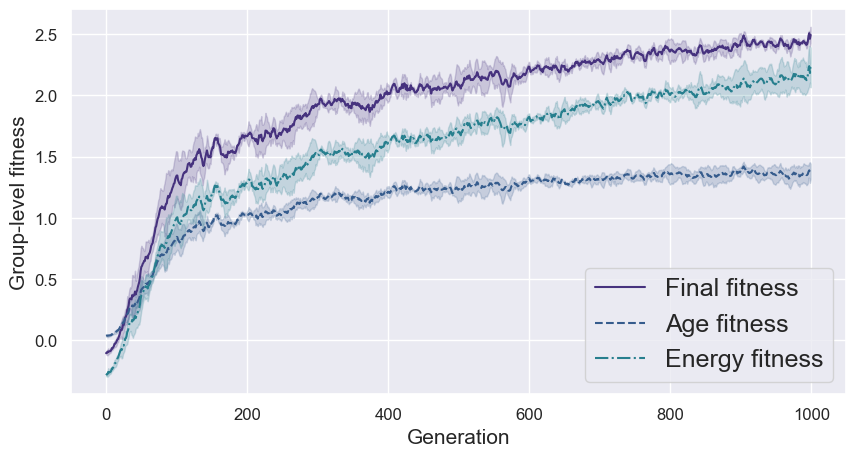

In [49]:
# combine all fitness plots in one plot with diff labels and colors
fig,ax = plt.subplots(figsize=(10,5))
mean_fitness_age = jnp.mean(jnp.stack([age_mass_fitness_seed_11, age_mass_fitness_seed_7, age_mass_fitness_seed_5]), axis=0)
std_fitness_age = jnp.std(jnp.stack([age_mass_fitness_seed_11, age_mass_fitness_seed_7, age_mass_fitness_seed_5]), axis=0)
mean_fitness_energy = jnp.mean(jnp.stack([energy_fitness_seed_11, energy_fitness_seed_7, energy_fitness_seed_5]), axis=0)
std_fitness_energy = jnp.std(jnp.stack([energy_fitness_seed_11, energy_fitness_seed_7, energy_fitness_seed_5]), axis=0)
mean_fitness = jnp.mean(jnp.stack([mean_fitness_seed_11, mean_fitness_seed_7, mean_fitness_seed_5]), axis=0)
std_fitness = jnp.std(jnp.stack([mean_fitness_seed_11, mean_fitness_seed_7, mean_fitness_seed_5]), axis=0)
generations = jnp.arange(mean_fitness.shape[0])
plt.plot(generations, mean_fitness, label='Final fitness', color=sns.color_palette(palette)[0], linestyle='-') # solid line
plt.fill_between(generations, mean_fitness - std_fitness, mean_fitness + std_fitness, color=sns.color_palette(palette)[0], alpha=0.2)
plt.plot(generations, mean_fitness_age, label='Age fitness', color=sns.color_palette(palette)[1], linestyle='--') # dashed line
plt.fill_between(generations, mean_fitness_age - std_fitness_age, mean_fitness_age + std_fitness_age, color=sns.color_palette(palette)[1], alpha=0.2)
plt.plot(generations, mean_fitness_energy, label='Energy fitness', color=sns.color_palette(palette)[2], linestyle='-.') # dash-dot line
plt.fill_between(generations, mean_fitness_energy - std_fitness_energy, mean_fitness_energy + std_fitness_energy, color=sns.color_palette(palette)[2], alpha=0.2)
plt.xlabel("Generation", fontsize=15)
plt.ylabel('Group-level fitness', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12)
#plt.title('Group-level selection fitness progress', fontsize=18)
plt.legend(loc='lower right', fontsize=18)
#save as svg and bb tight
plt.savefig('fitness_progress_combined.svg', bbox_inches='tight')
plt.show()


In [52]:
#plot the increse in exchange energy over generations
exchange_energy_seed_11 = jnp.load('./seed_11/avg_interaction_energy_list.npy')
exchange_energy_seed_7 = jnp.load('./seed_7/avg_interaction_energy_list.npy')
exchange_energy_seed_5 = jnp.load('./seed_5/avg_interaction_energy_list.npy')

exchange_energy_seed_11 = moving_average(exchange_energy_seed_11, moving_average_window)
exchange_energy_seed_7 = moving_average(exchange_energy_seed_7, moving_average_window)
exchange_energy_seed_5 = moving_average(exchange_energy_seed_5, moving_average_window)

print(exchange_energy_seed_11.shape)

(1000,)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


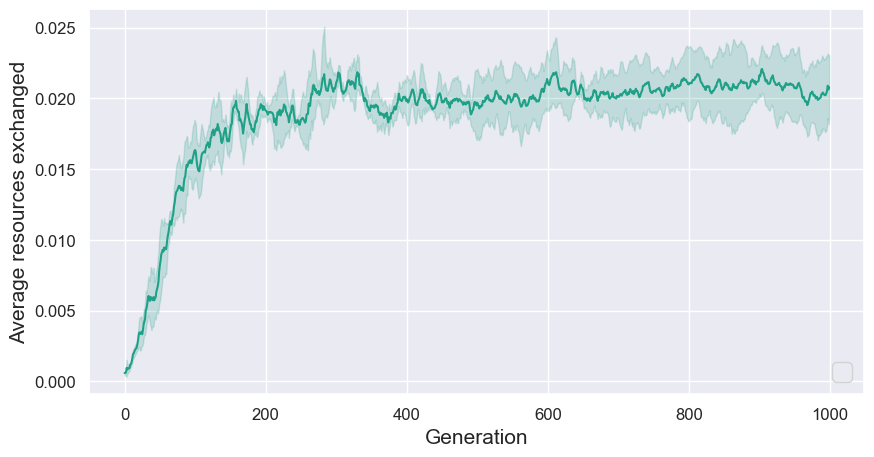

In [55]:
fig,ax = plt.subplots(figsize=(10,5))
mean_exchange_energy = jnp.mean(jnp.stack([exchange_energy_seed_11, exchange_energy_seed_7, exchange_energy_seed_5]), axis=0)
std_exchange_energy = jnp.std(jnp.stack([exchange_energy_seed_11, exchange_energy_seed_7, exchange_energy_seed_5]), axis=0)
generations = jnp.arange(mean_exchange_energy.shape[0])
plt.plot(generations, mean_exchange_energy, color=sns.color_palette(palette)[3]) # solid line
plt.fill_between(generations, mean_exchange_energy - std_exchange_energy, mean_exchange_energy + std_exchange_energy, color=sns.color_palette(palette)[3], alpha=0.2)
plt.xlabel("Generation", fontsize=15)
plt.ylabel('Average resources exchanged', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12)
#plt.title('Mean interaction energy progress', fontsize=18)
plt.legend(loc='lower right', fontsize=18)
plt.savefig('interaction_energy_progress.svg', bbox_inches='tight')
plt.show()